# Per-frame output of each benchmarked method

All methods are evaluated on the same frames of the same trajectory, each
reporting in its native output units. Every value below — each method's claim,
its native outputs, its verdict, its standing against its own declared
thresholds and its measured discrimination on this trajectory — is read or
computed from the run artefacts when the cell executes. Change `PROTEIN` and
`RANGE_NS` in the first cell to run the same comparison on another system.


In [1]:
PROTEIN = "gramicidin"   # system id from configs/
CONDITION = None          # None -> first condition
REPLICA = None            # None -> first replica
RANGE_NS = (50.0, 150.0)  # stretch of the trajectory to display, in ns
MOMENT_NS = None          # the single frame to dissect; None -> middle of RANGE_NS

In [2]:
import json
import warnings

warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd

import predict_lib as pl
from pcm2.baselines.published import RAO_DEWETTING_THRESHOLD_KJMOL
from pcm2.runtime import run_dir

cfg = pl.resolve_config(PROTEIN)
cond, rep = pl.resolve_replica(cfg, CONDITION, REPLICA)
root = run_dir(cfg)

b = pd.read_parquet(root / "benchmark" / "benchmark.parquet")
b = b[(b["condition"] == cond["id"]) & (b["replica"] == rep["id"])]
tau = float(b["tau_ps"].iloc[0])
t_ns = b["time_ps"] / 1000.0
sel = (t_ns >= RANGE_NS[0]) & (t_ns <= RANGE_NS[1])
b, t_ns = b[sel], t_ns[sel]

ev = pd.read_parquet(root / "events" / "events.parquet")
ev = ev[(ev["condition"] == cond["id"]) & (ev["replica"] == rep["id"])]
crossings_ns = ev["t_exit_ps"].to_numpy() / 1000.0
crossings_ns = crossings_ns[(crossings_ns >= RANGE_NS[0]) & (crossings_ns <= RANGE_NS[1])]

summary = json.loads((root / "benchmark" / "summary.json").read_text())

# the measured descriptors of the same frames, the inputs of every method
feats = pd.read_parquet(root / "features" / "features.parquet")
feats = feats[(feats["condition"] == cond["id"]) & (feats["replica"] == rep["id"])]

print(f"{cfg['system.id']} | {cond['id']}/{rep['id']} | "
      f"{len(b)} frames in {RANGE_NS[0]:.0f}-{RANGE_NS[1]:.0f} ns | "
      f"tau = {tau:.0f} ps | {len(crossings_ns)} crossings in view")

gramicidin | 298K_2Msalt/01 | 625 frames in 50-150 ns | tau = 2000 ps | 5 crossings in view


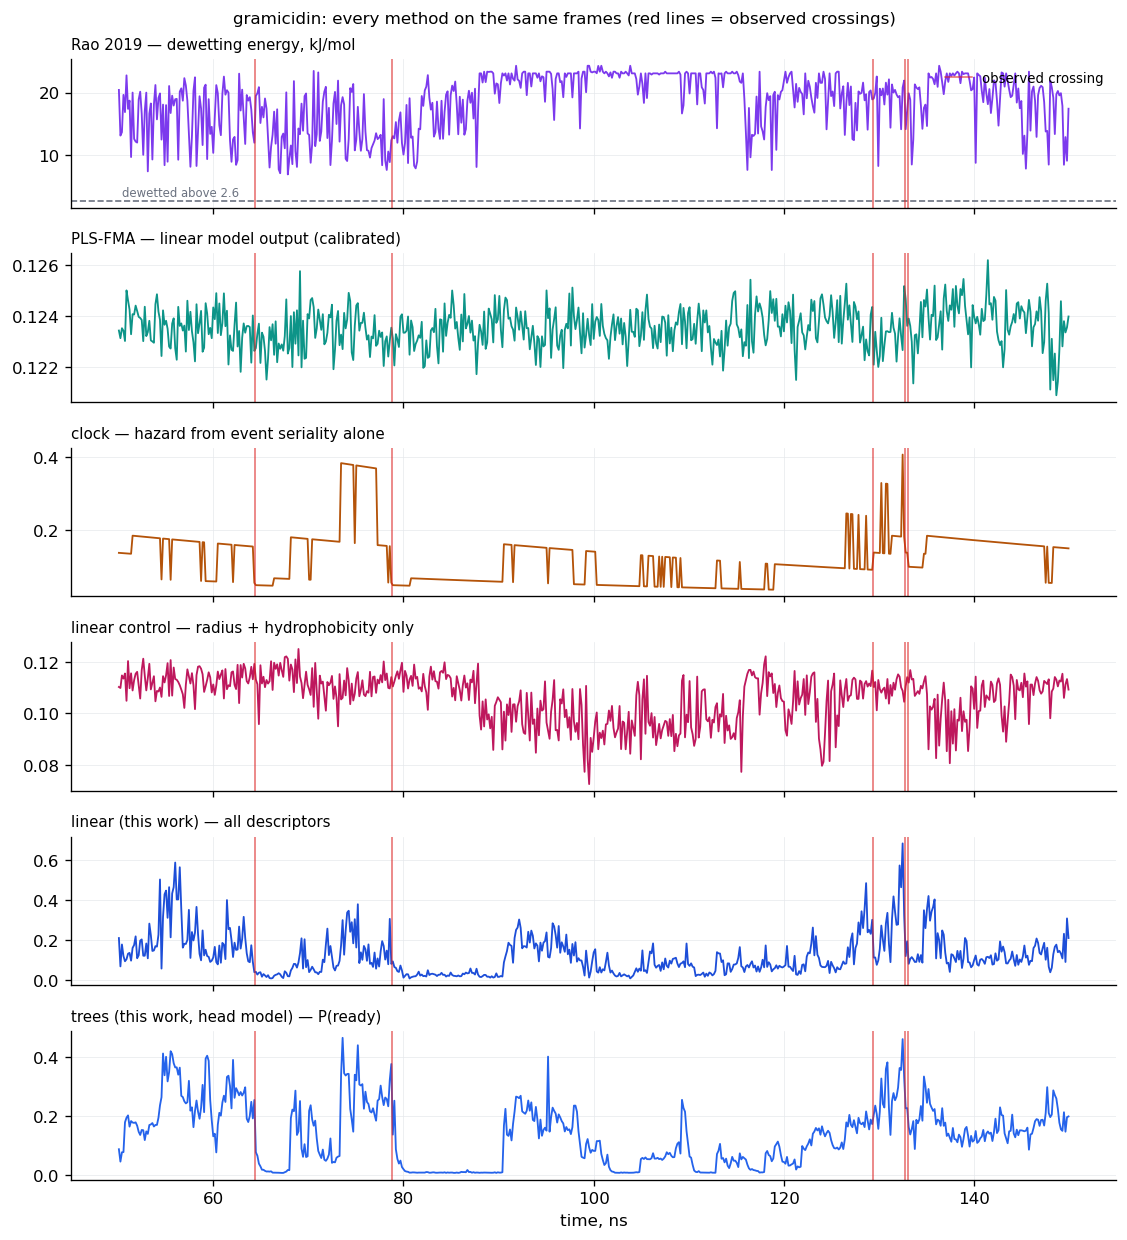

In [3]:
import matplotlib.pyplot as plt

PANELS = [
    ("published_rao2019_energy_kJmol", "Rao 2019 — dewetting energy, kJ/mol",
     "#7c3aed", {"threshold": RAO_DEWETTING_THRESHOLD_KJMOL,
                  "threshold_label": "dewetted above 2.6"}),
    ("plsfma_coords_prob", "PLS-FMA — linear model output (calibrated)",
     "#0d9488", {}),
    ("clock_prob", "clock — hazard from event seriality alone", "#b45309", {}),
    ("linear_control_structural_prob",
     "linear control — radius + hydrophobicity only", "#be185d", {}),
    ("linear_prob", "linear (this work) — all descriptors", "#1d4ed8", {}),
    ("trees_prob", "trees (this work, head model) — P(ready)", "#2563eb", {}),
]

avail = [p for p in PANELS if p[0] in b.columns and b[p[0]].notna().any()]
fig, axes = plt.subplots(len(avail), 1, figsize=(9.5, 1.75 * len(avail)),
                         dpi=120, sharex=True)
for ax, (col, title, color, extra) in zip(np.atleast_1d(axes), avail):
    ax.plot(t_ns, b[col], lw=1.1, color=color)
    if "threshold" in extra:
        ax.axhline(extra["threshold"], color="#6b7280", lw=1.0, ls="--")
        ax.annotate(extra["threshold_label"], xy=(t_ns.iloc[0], extra["threshold"]),
                    xytext=(2, 3), textcoords="offset points",
                    fontsize=7, color="#6b7280")
    for k, tx in enumerate(crossings_ns):
        ax.axvline(tx, color="#dc2626", lw=0.9, alpha=0.7,
                   label="observed crossing" if k == 0 else None)
    ax.set_title(title, fontsize=9, loc="left")
    ax.grid(color="#e5e7eb", lw=0.4)
    ax.spines[["top", "right"]].set_visible(False)
axes = np.atleast_1d(axes)
axes[-1].set_xlabel("time, ns")
handles, labels = axes[0].get_legend_handles_labels()
if handles:
    axes[0].legend(loc="upper right", fontsize=8, frameon=False)
fig.suptitle(f"{cfg['system.id']}: every method on the same frames "
             f"(red lines = observed crossings)", fontsize=10)
fig.tight_layout()
plt.show()

Red lines mark completed crossings; a trace carrying readiness information
rises before them and stays low elsewhere. The Rao energy reports whether the
constriction is dewetted, so on a channel that is always wet (or always
dewetted) it is nearly flat: correct about its own claim, uninformative about
the timing of crossings. The clock baseline tracks event seriality without
reading the structure, so its score is the share of the signal that lives in
timing alone.


In [4]:
# ONE MOMENT, EVERY METHOD — the full output of each method at a single frame.
# Thresholds, percentiles and discrimination are computed here from this run;
# "claims" is the method's own declaration recorded by the benchmark step.

moment_ns = float(np.mean(RANGE_NS)) if MOMENT_NS is None else float(MOMENT_NS)
i = (t_ns - moment_ns).abs().idxmin()
row = b.loc[i]
frow = feats.iloc[(feats["time_ps"] - row["time_ps"]).abs().argsort().iloc[0]]

# thresholds a method declares up front, in its own units
DECLARED = {"published_rao2019_energy_kJmol": (RAO_DEWETTING_THRESHOLD_KJMOL,
                                               "dewetted at or above"),
            "published_rao2019_win_energy_kJmol": (RAO_DEWETTING_THRESHOLD_KJMOL,
                                                   "dewetted at or above")}
# the measured descriptors each reading can be traced back to
RESTS_ON = {"published_rao2019": ["geo_r_constriction_A", "hyd_lining_hydrophobicity"],
            "published_rao2019_win": ["geo_r_constriction_A", "hyd_lining_hydrophobicity"],
            "published_rao2019_sigma": ["geo_r_constriction_A", "hyd_lining_hydrophobicity"]}
SUFFIX_UNITS = {"prob": "", "energy_kJmol": " kJ/mol", "score": ""}
ARMS = [m["method"] for m in summary]


def outputs_of(arm):
    """Native output columns of one arm, discovered from the benchmark table.

    A column belongs to the longest arm name that prefixes it, so the sigma
    variant does not claim the columns of the arm it extends.
    """
    out = []
    for c in b.columns:
        owner = max((a for a in ARMS if c.startswith(a + "_")),
                    key=len, default=None)
        if owner != arm:
            continue
        suffix = c[len(arm) + 1:]
        if suffix in SUFFIX_UNITS or suffix == "verdict":
            out.append((c, suffix))
    return out


def pct_of_unit(col, value):
    """Where this frame sits in the method's own distribution over the window."""
    v = b[col].to_numpy(float)
    v = v[np.isfinite(v)]
    return 100.0 * (v <= value).mean() if len(v) else float("nan")


print(f"frame t = {row['time_ps']:.0f} ps ({row['time_ps']/1000:.1f} ns) | "
      f"truth: a crossing completes within tau = {tau:.0f} ps -> "
      f"{bool(row['truth_crossing_within_tau'])}")
print("=" * 78)

for meth in summary:
    arm = meth["method"]
    cols = outputs_of(arm)
    if not cols:
        continue
    print(f"\n{arm}")
    print(f"  claims        : {meth['claims']}")
    reported = []
    for col, suffix in cols:
        val = row.get(col, np.nan)
        if suffix == "verdict":
            reported.append(f"verdict = {val}")
            continue
        if pd.isna(val):
            reported.append(f"{suffix} = refused (not measurable on this frame)")
            continue
        unit = SUFFIX_UNITS.get(suffix, "")
        line = f"{suffix} = {val:.3f}{unit}"
        if col in DECLARED:
            thr, phrase = DECLARED[col]
            state = "yes" if val >= thr else "no"
            line += f"  [{phrase} {thr}: {state}]"
        line += f"  ({pct_of_unit(col, val):.0f}th percentile of this window)"
        reported.append(line)
    for r in reported:
        print(f"  reports       : {r}")
    for c in RESTS_ON.get(arm, []):
        if c in frow.index and pd.notna(frow[c]):
            print(f"  rests on      : {c} = {frow[c]:.3f}")
    ap = meth.get("ap_over_chance")
    if ap is not None and np.isfinite(ap):
        reading = ("separates pre-crossing frames" if ap >= 1.20 else
                   "at chance" if ap >= 0.90 else "ranks the wrong way round")
        print(f"  on this system: {ap:.2f}x chance over {meth['frames_judged']} "
              f"frames -> {reading}")
    acc, bal = meth["verdict_accuracy"], meth["balanced_accuracy"]
    source = (" (near 0.5 balanced: the accuracy comes from the class prior, "
              "not from telling the classes apart)" if bal < 0.55 else "")
    print(f"  verdict acc.  : {acc:.3f} | balanced {bal:.3f}{source}")

frame t = 100000 ps (100.0 ns) | truth: a crossing completes within tau = 2000 ps -> False

trees
  claims        : this work (head model): P(crossing completes within tau), READY/NOT_READY verdict and mechanism axis (pore state) per frame
  reports       : prob = 0.083  (38th percentile of this window)
  reports       : verdict = NOT_READY
  on this system: 2.59x chance over 12385 frames -> separates pre-crossing frames
  verdict acc.  : 0.801 | balanced 0.698

clock
  claims        : temporal null: event seriality only (time since last crossing, event rate, pore ion count); no structural input
  reports       : prob = 0.141  (54th percentile of this window)
  reports       : verdict = NOT_READY
  on this system: 1.53x chance over 12385 frames -> separates pre-crossing frames
  verdict acc.  : 0.666 | balanced 0.638

linear
  claims        : this work (linear branch): same probabilistic claim, ridge-logistic on all descriptors
  reports       : prob = 0.139  (68th percentile of this w

In [5]:
# This work at the same frame: calibrated probability, verdict, mechanism axes
# with the descriptor behind each, and the measured pore state.

print(f"frame t = {row['time_ps']:.0f} ps  |  pipeline answer stored with the run")
print("=" * 78)
for col, label in [("pcm_prob_ready", "P(ready)"), ("pcm_verdict", "verdict"),
                   ("pcm_pore_state", "mechanism axis"), ("pcm_reason", "reason")]:
    if col in b.columns and pd.notna(row.get(col)):
        v = row[col]
        print(f"  {label:16s}: {v:.3f}" if isinstance(v, float) else
              f"  {label:16s}: {v}")

bundle = pl.load_pooled_model(tau_ps=tau, variant="physics_only")
have = [c for c in bundle["columns"] if c in feats.columns]
if len(have) == len(bundle["columns"]):
    one = frow[bundle["columns"]].to_frame().T
    pred = pl.predict_rows(bundle, pd.concat(
        [frow[["condition", "replica", "time_ps"]].to_frame().T, one], axis=1))
    reasons = pl.explain_rows(bundle, one, top_k=len(pl.AXES))[0]
    print(f"\n  pooled monitor (trained on the conducting pool, this protein "
          f"held out of nothing here): P(ready) = {pred['p_ready'].iloc[0]:.3f}, "
          f"threshold {bundle['threshold']:.3f} -> "
          f"{'READY' if pred['ready'].iloc[0] else 'NOT READY'}")
    print("  mechanism axes pushing the verdict, strongest first:")
    for r in reasons:
        val = "n/a" if r["column_value"] is None else f"{r['column_value']:.3f}"
        print(f"    {r['weight']:5.1%}  {r['axis']:<30s} "
              f"top column {r['top_column']} = {val}")
else:
    print("\n  pooled monitor: refused, this system lacks "
          f"{len(bundle['columns']) - len(have)} model columns")

print("\n  measured state of the same frame (no model, no horizon):")
for group, items in pl.SNAPSHOT_QUANTITIES:
    vals = [(lab, frow[c], unit) for c, lab, unit in items
            if c in frow.index and pd.notna(frow[c])]
    if not vals:
        continue
    print(f"    {group}")
    for lab, v, unit in vals:
        print(f"      {lab:<46s} {v:8.2f} {unit}")

frame t = 100000 ps  |  pipeline answer stored with the run
  P(ready)        : 0.083
  verdict         : NOT_READY
  mechanism axis  : permeant delivery
  reason          : dlv_t_since_cross_ps=2.12e+04 (contribution -0.359 logit toward not-ready)

  pooled monitor (trained on the conducting pool, this protein held out of nothing here): P(ready) = 0.039, threshold 0.290 -> NOT READY
  mechanism axes pushing the verdict, strongest first:
    29.0%  pathway/lining rearrangement   top column geo_r_bin4_rel = 2.106
    28.8%  permeant delivery              top column dlv_t_since_cross_ps = 21200.000
    23.1%  constriction dehydration       top column hyd_water_bin5_n = 1.000
    14.3%  column immobility              top column dyn_wet_state_age_ps = 960.000
     4.7%  water-wire rupture             top column ww_dipole_cos_mean = 0.645

  measured state of the same frame (no model, no horizon):
    pore geometry
      constriction radius                                0.77 Å
      constr

In [6]:
# CAPABILITY MATRIX — which outputs each method produced over this trajectory.
rows = []
for meth in summary:
    arm = meth["method"]
    cols = outputs_of(arm)
    kinds = {suffix for _, suffix in cols}
    finite = {c: int(np.isfinite(pd.to_numeric(b[c], errors="coerce")).sum())
              for c, s in cols if s != "verdict"}
    rows.append({
        "method": arm,
        "native score": next((s for s in kinds if s != "verdict"), "-"),
        "calibrated probability": "yes" if "prob" in kinds else "no",
        "per-frame verdict": "yes" if "verdict" in kinds else "no",
        "mechanism axis": "yes" if arm == "trees" else "no",
        "frames answered": max(finite.values()) if finite else 0,
        "AP / chance": round(meth["ap_over_chance"], 2)
        if meth.get("ap_over_chance") is not None else None,
    })
pd.DataFrame(rows).set_index("method")

,native score,calibrated probability,per-frame verdict,mechanism axis,frames answered,AP / chance
method,,,,,,
trees,prob,yes,yes,yes,625,2.59
clock,prob,yes,yes,no,625,1.53
linear,prob,yes,yes,no,625,2.66
linear_control_structural,prob,yes,yes,no,625,0.97
plsfma_coords,prob,yes,yes,no,625,1.04
published_rao2019,energy_kJmol,no,yes,no,625,1.06
published_rao2019_win,energy_kJmol,no,yes,no,625,1.06
published_rao2019_sigma,score,no,yes,no,625,0.97


In [7]:
# Headline metrics for this system, from the benchmark artifact.
df = (pd.DataFrame(summary)
      .rename(columns={"verdict_accuracy": "verdict accuracy",
                       "balanced_accuracy": "balanced accuracy",
                       "ap_over_chance": "AP / chance"})
      [["method", "frames_judged", "verdict accuracy", "balanced accuracy",
        "AP / chance"]]
      .set_index("method")
      .sort_values("AP / chance", ascending=False))
df.round(3)

,frames_judged,verdict accuracy,balanced accuracy,AP / chance
method,,,,
linear,12385,0.792,0.681,2.657
trees,12385,0.801,0.698,2.591
clock,12385,0.666,0.638,1.535
published_rao2019_win,12385,0.890,0.500,1.062
published_rao2019,12385,0.890,0.500,1.057
plsfma_coords,12385,0.310,0.580,1.035
linear_control_structural,12385,0.282,0.549,0.973
published_rao2019_sigma,12385,0.890,0.500,0.972


## Notes

- Every method is run on the same frames and judged against what it claims to
  predict; the readings above are its native per-frame output.
- The Rao heuristic and PLS-FMA are implemented from the authors' own materials
  (vendored energy surface and hydropathy scale with checksums; a port of the
  g_fma PLS core). Their weakness at forecasting readiness follows from the
  question they answer rather than from the implementation:
  `runs/plsfma-selfcheck/` shows PLS-FMA performing as designed in its published
  regime.
- The capability matrix lists which outputs each method emits; it is not a
  ranking. A method that emits one number per frame answers a narrower question,
  and the matrix records how much of the readiness question each output form can
  carry.
